### LangGraph Learning
* A simple ChartBot


In [1]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [2]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph,START,END
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages


llm_model = ChatGroq(model="qwen/qwen3-32b")

In [3]:
from langchain_tavily import TavilySearch

tav_tool = TavilySearch(max_results=2)


def multiply_tool(a: int, b: int) -> int:
    """Multiplies two numbers together. """
    return a * b

### Tavily and Tool Calling


In [4]:
tools = [tav_tool, multiply_tool]
llm_with_tools = llm_model.bind_tools(tools)

In [5]:
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import InMemorySaver

memory = InMemorySaver()
class Chat(TypedDict):
    messages : Annotated[list,add_messages]
def llm_with_tools_node(state: Chat) -> Chat:
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph = StateGraph(Chat)
graph.add_node("llm_with_tools_node", llm_with_tools_node)
graph.add_node("tools", ToolNode(tools))
graph.add_edge(START, "llm_with_tools_node")
graph.add_conditional_edges("llm_with_tools_node",tools_condition)
graph.add_edge("tools", END)
graph_state = graph.compile(checkpointer=memory)

In [6]:
config = { "configurable":{"thread_id":"test_2"}}

In [7]:
res = graph_state.invoke({"messages":"my name is James Nithil"}, config=config)

In [8]:
for m in res["messages"]:
    m.pretty_print()

================================ Human Message =================================

my name is James Nithil
================================== Ai Message ==================================

Hello James Nithil! How can I assist you today?


In [9]:
response = graph_state.invoke({"messages":"what is my name dude?"}, config=config)
for res in response["messages"]:
    res.pretty_print()

================================ Human Message =================================

my name is James Nithil
================================== Ai Message ==================================

Hello James Nithil! How can I assist you today?
================================ Human Message =================================

what is my name dude?
================================== Ai Message ==================================

Your name is James Nithil! 😊


### React Agent's


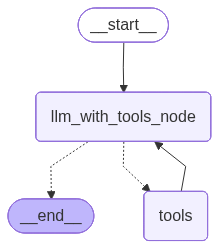

In [10]:
class ReactAgent(TypedDict):
    messages : Annotated[list,add_messages]
def llm_with_tools_node(state: ReactAgent) -> ReactAgent:
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph = StateGraph(ReactAgent)
graph.add_node("llm_with_tools_node", llm_with_tools_node)
graph.add_node("tools", ToolNode(tools))
graph.add_edge(START, "llm_with_tools_node")
graph.add_conditional_edges("llm_with_tools_node",tools_condition)
graph.add_edge("tools","llm_with_tools_node")
graph_state = graph.compile()

from IPython.display import Image,display

display(Image(graph_state.get_graph().draw_mermaid_png()))

In [27]:
react_response = graph_state.invoke({"messages":"what recent ai news then 234 times 223"})
for m in react_response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what recent ai news then 234 times 223
================================== Ai Message ==================================
Tool Calls:
  tavily_search (5s03eczkj)
 Call ID: 5s03eczkj
  Args:
    query: recent AI news
    time_range: week
    topic: news
  multiply_tool (d20ng9c5s)
 Call ID: d20ng9c5s
  Args:
    a: 234
    b: 223
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.axios.com/2026/06/08/ai-news-nvidia-cosmos-3-openai-sites-solara-rtx-spark", "title": "Axios C-Suite: 3 new AI developments for the week of June 6 - Axios", "score": 0.7783298, "published_date": "Mon, 08 Jun 2026 09:57:05 GMT", "content": "# Axios C-Suite: 3 new AI developments for the week of June 6. Fast action AI software:** OpenAI launched Sites, a Codex featur